<a href="https://colab.research.google.com/github/Data-Creater-Atlas/Data-Atlas/blob/Seongjong/swinunet_4_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title 1. 드라이브 마운트 및 라이브러리 설치
from google.colab import drive
import os, glob, random, re, math, warnings, json, time, io, datetime
from pathlib import Path
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models

# --- 구글 드라이브 연결 ---
drive.mount('/content/drive')

# --- 필요 라이브러리 설치 ---
!pip -q install -U tifffile imagecodecs

# --- GPU 및 AMP(혼합 정밀도) 설정 ---
print("TF Version:", tf.__version__)
try:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("AMP Policy:", tf.keras.mixed_precision.global_policy())
except Exception as e:
    print(f"AMP 설정 실패: {e}")

print("\n✅ 환경 설정이 완료되었습니다.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TF Version: 2.19.0
AMP Policy: <DTypePolicy "mixed_float16">

✅ 환경 설정이 완료되었습니다.


In [2]:
#@title 2. 데이터셋 경로 설정
from pathlib import Path

# --- ⚠️ 본인의 구글 드라이브 경로 ---
ROOT = Path("/content/drive/MyDrive/Data Camp/53.대기오염 배출원 공간 분포 데이터/3.개방데이터/1.데이터")

# --- 미션 4-1 (SN10) 데이터 폴더 경로 ---
TR_IMG_DIR    = ROOT / "Training/01.원천데이터/TS_SN10_SN10"
TR_LABEL_DIR  = ROOT / "Training/02.라벨링데이터/TL_SN10"
VAL_IMG_DIR   = ROOT / "Validation/01.원천데이터/VS_SN10_SN10"
VAL_LABEL_DIR = ROOT / "Validation/02.라벨링데이터/VL_SN10"

print("✅ 데이터 경로가 설정되었습니다.")
print(f"학습 이미지 경로: {TR_IMG_DIR}")

✅ 데이터 경로가 설정되었습니다.
학습 이미지 경로: /content/drive/MyDrive/Data Camp/53.대기오염 배출원 공간 분포 데이터/3.개방데이터/1.데이터/Training/01.원천데이터/TS_SN10_SN10


In [3]:
#@title 3. 데이터 파일 확인 (이미지 & 라벨 페어링)
def list_pairs(img_dir: Path, lbl_dir: Path):
    imgs = sorted([p for p in Path(img_dir).glob("*.tif")])
    lbls = []
    miss = []
    for p in imgs:
        q = Path(lbl_dir) / (p.stem + ".tif")
        if not q.exists():
            miss.append(p.stem)
        else:
            lbls.append(q)
    if miss:
        print(f"[경고] 라벨 파일 누락 {len(miss)}개: {miss[:3]}")
        imgs = [p for p in imgs if (lbl_dir / f"{p.stem}.tif").exists()]

    if len(imgs) == 0:
        print(f"❌ [오류] {img_dir} 경로에서 .tif 파일을 찾지 못했습니다. 2번 셀의 경로를 다시 확인해주세요.")

    return imgs, lbls

tr_imgs, tr_lbls = list_pairs(TR_IMG_DIR, TR_LABEL_DIR)
va_imgs, va_lbls = list_pairs(VAL_IMG_DIR, VAL_LABEL_DIR)
print(f"✅ 파일 페어링 완료: [학습셋] {len(tr_imgs)}쌍, [검증셋] {len(va_imgs)}쌍")

✅ 파일 페어링 완료: [학습셋] 8000쌍, [검증셋] 1000쌍


In [4]:
#@title 4. 데이터 로더 및 증강(Augmentation) 함수 정의
import tensorflow as tf
import tifffile as tiff
import numpy as np
import io, time

CLIP_MAX = 10000.0
IMG_SIZE    = (256, 256)
NUM_CLASSES = 2
BATCH_SIZE  = 16  # OOM 발생 시 8로 줄이세요
AUTOTUNE    = tf.data.AUTOTUNE
SEED        = 42
EXPECTED_CHANNELS = 5 # RGB + NO2 + AIR

# --- TIF 파일 로더 함수 ---
def decode_img_from_bytes_np(b):
    try:
        arr = tiff.imread(io.BytesIO(memoryview(b).tobytes()))

        # 차원 정리: (C, H, W) -> (H, W, C)
        if arr.ndim == 3 and arr.shape[0] <= 20:
            arr = np.moveaxis(arr, 0, -1)
        if arr.ndim == 2:
            arr = arr[..., np.newaxis]

        # --- [핵심] 채널 수 강제 맞춤 (5채널) ---
        current_channels = arr.shape[-1]
        if current_channels < EXPECTED_CHANNELS:
            # 채널이 부족하면 0으로 채움 (Padding)
            pad_width = EXPECTED_CHANNELS - current_channels
            arr = np.pad(arr, ((0,0), (0,0), (0, pad_width)), mode='constant')
        elif current_channels > EXPECTED_CHANNELS:
            # 채널이 많으면 앞쪽 5개만 사용 (Slicing)
            arr = arr[..., :EXPECTED_CHANNELS]

        arr = arr.astype(np.float32, copy=False)
        arr = np.clip(arr, 0, CLIP_MAX) / CLIP_MAX
        return np.nan_to_num(arr, nan=0.0)
    except:
        return np.zeros((512, 512, EXPECTED_CHANNELS), dtype=np.float32)

def decode_mask_from_bytes_np(b):
    try:
        m = tiff.imread(io.BytesIO(memoryview(b).tobytes()))
        if m.ndim == 3: m = m[..., 0]
        if not np.issubdtype(m.dtype, np.integer): m = m.astype(np.int64, copy=False)
        m = (m == 10).astype(np.int32, copy=False)
        return m
    except: return np.zeros((512, 512), dtype=np.int32)

def load_pair(img_path, lbl_path):
    img = tf.numpy_function(decode_img_from_bytes_np, [tf.io.read_file(img_path)], tf.float32)
    msk = tf.numpy_function(decode_mask_from_bytes_np, [tf.io.read_file(lbl_path)], tf.int32)

    # ⚠️ 5채널로 shape 고정
    img.set_shape([None, None, EXPECTED_CHANNELS])
    msk.set_shape([None, None])

    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    msk = tf.image.resize(msk[..., None], IMG_SIZE, method="nearest")
    return img, tf.cast(msk, tf.float32)

# --- 데이터 증강 함수 ---
def strong_aug(img, m):
    if tf.random.uniform([]) < 0.5:
        img = tf.image.flip_left_right(img)
        m = tf.image.flip_left_right(m)

    if tf.random.uniform([]) < 0.5:
        img = tf.image.flip_up_down(img)
        m = tf.image.flip_up_down(m)

    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    m = tf.image.rot90(m, k)

    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, m

print("✅ 데이터 로더 (5채널 강제 맞춤)가 정의되었습니다.")

✅ 데이터 로더 (5채널 강제 맞춤)가 정의되었습니다.


In [5]:
#@title 5. TensorFlow 데이터셋 생성
def make_ds(imgs, lbls, train=True, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices(([str(p) for p in imgs], [str(p) for p in lbls]))
    if train:
        ds = ds.shuffle(len(imgs), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_pair, num_parallel_calls=AUTOTUNE)
    if train:
        ds = ds.map(strong_aug, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(tr_imgs, tr_lbls, train=True)
valid_ds = make_ds(va_imgs, va_lbls, train=False)

print(f"✅ 학습 및 검증 데이터셋이 생성되었습니다. (Batch: {BATCH_SIZE})")

✅ 학습 및 검증 데이터셋이 생성되었습니다. (Batch: 16)


In [6]:
#@title 6. Swin-Unet 모델 정의 (KerasTensor 오류 수정됨)
import tensorflow as tf
from tensorflow.keras import layers, models

# --- 1. 기본 컴포넌트 ---
class WindowAttention(layers.Layer):
    def __init__(self, dim, num_heads=8, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = layers.Dense(dim * 3)
        self.proj = layers.Dense(dim)

    def call(self, x):
        B = tf.shape(x)[0]
        N = tf.shape(x)[1]
        C = tf.shape(x)[2]
        qkv = self.qkv(x)
        qkv = tf.reshape(qkv, (B, N, 3, self.num_heads, self.head_dim))
        qkv = tf.transpose(qkv, (2, 0, 3, 1, 4))
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ tf.transpose(k, (0, 1, 3, 2))) * self.scale
        attn = tf.nn.softmax(attn, axis=-1)
        x = (attn @ v)
        x = tf.transpose(x, (0, 2, 1, 3))
        x = tf.reshape(x, (B, N, C))
        return self.proj(x)

class SwinBlock(layers.Layer):
    def __init__(self, dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.norm1 = layers.LayerNormalization(epsilon=1e-5)
        self.attn = WindowAttention(dim, num_heads=num_heads)
        self.norm2 = layers.LayerNormalization(epsilon=1e-5)
        self.mlp = models.Sequential([
            layers.Dense(dim * 4, activation='gelu'),
            layers.Dense(dim)
        ])
    def call(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class PatchEmbedding(layers.Layer):
    def __init__(self, embed_dim=96, patch_size=4, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.proj = layers.Conv2D(embed_dim, kernel_size=patch_size, strides=patch_size, padding='SAME')
        self.norm = layers.LayerNormalization(epsilon=1e-5)
    def call(self, x):
        x = self.proj(x)
        B = tf.shape(x)[0]
        H = tf.shape(x)[1]
        W = tf.shape(x)[2]
        C = tf.shape(x)[3]
        x = tf.reshape(x, (B, H * W, C))
        return self.norm(x)

# --- 2. 모델 조립 (layers.Reshape 적용) ---
def build_swin_unet(img_size=IMG_SIZE, num_classes=1, embed_dim=96):
    # 5채널 입력 (RGB+NO2+AIR)
    inputs = layers.Input(shape=(*img_size, 5))

    # [Encoder]
    x = PatchEmbedding(embed_dim=embed_dim)(inputs) # 64x64

    # Stage 1
    x = SwinBlock(embed_dim, num_heads=3)(x)
    x = SwinBlock(embed_dim, num_heads=3)(x)
    skip1 = layers.Reshape((64, 64, embed_dim))(x)

    # Downsample 1
    x_down1 = layers.Conv2D(embed_dim*2, 2, strides=2, padding='same')(skip1)
    x = layers.Reshape((-1, embed_dim*2))(x_down1)

    # Stage 2
    x = SwinBlock(embed_dim*2, num_heads=6)(x)
    x = SwinBlock(embed_dim*2, num_heads=6)(x)
    skip2 = layers.Reshape((32, 32, embed_dim*2))(x)

    # Downsample 2
    x_down2 = layers.Conv2D(embed_dim*4, 2, strides=2, padding='same')(skip2)
    x = layers.Reshape((-1, embed_dim*4))(x_down2)

    # Bottleneck
    x = SwinBlock(embed_dim*4, num_heads=12)(x)
    x = SwinBlock(embed_dim*4, num_heads=12)(x)

    # [Decoder]
    x = layers.Reshape((16, 16, embed_dim*4))(x)
    x_up1 = layers.Conv2DTranspose(embed_dim*2, 2, strides=2, padding='same')(x)

    x = layers.Concatenate()([x_up1, skip2])
    x = layers.Reshape((-1, embed_dim*4))(x)
    x = layers.Dense(embed_dim*2)(x)

    x = SwinBlock(embed_dim*2, num_heads=6)(x)
    x = SwinBlock(embed_dim*2, num_heads=6)(x)

    x = layers.Reshape((32, 32, embed_dim*2))(x)
    x_up2 = layers.Conv2DTranspose(embed_dim, 2, strides=2, padding='same')(x)

    x = layers.Concatenate()([x_up2, skip1])
    x = layers.Reshape((-1, embed_dim*2))(x)
    x = layers.Dense(embed_dim)(x)

    x = SwinBlock(embed_dim, num_heads=3)(x)
    x = SwinBlock(embed_dim, num_heads=3)(x)

    # [Head]
    x = layers.Reshape((64, 64, embed_dim))(x)
    x = layers.Conv2DTranspose(embed_dim, 4, strides=4, padding='same')(x)
    outputs = layers.Conv2D(num_classes, 1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs, name="Swin_Unet_5Ch")
    return model

model = build_swin_unet()
model.summary()
print("\n✅ Swin-Unet (5채널) 모델이 정의되었습니다.")

Model: "Swin_Unet_5Ch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 5)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_embedding     │ (None, 4096, 96)  │      7,968 │ input_layer[0][0] │
│ (PatchEmbedding)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ swin_block          │ (None, 4096, 96)  │    111,840 │ patch_embedding[… │
│ (SwinBlock)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ swin_block_1        │ (None, 4096, 96)  │    111,840 │ swin_block[0][0]  │
│ (SwinBlock)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 64, 64,    │          0 │ swin_block_1[0][… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     73,920 │ reshape[0][0]     │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1024, 192) │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ swin_block_2        │ (None, 1024, 192) │    444,864 │ reshape_1[0][0]   │
│ (SwinBlock)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ swin_block_3        │ (None, 1024, 192) │    444,864 │ swin_block_2[0][… │
│ (SwinBlock)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 32, 32,    │          0 │ swin_block_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │    295,296 │ reshape_2[0][0]   │
│                     │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 256, 384)  │          0 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ swin_block_4        │ (None, 256, 384)  │  1,774,464 │ reshape_3[0][0]   │
│ (SwinBlock)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ swin_block_5        │ (None, 256, 384)  │  1,774,464 │ swin_block_4[0][… │
│ (SwinBlock)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 16, 16,    │          0 │ swin_block_5[0][… │
│                     │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │    295,104 │ reshape_4[0][0]   │
│ (Conv2DTranspose)   │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 384)              │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 6,761,953 (25.79 MB)

 Trainable params: 6,761,953 (25.79 MB)

 Non-trainable params: 0 (0.00 B)


✅ Swin-Unet (5채널) 모델이 정의되었습니다.


In [7]:
#@title 7. 손실/지표/스케줄러
import math

# --- 1. 강력한 손실 함수 정의 (BCE + Dice) ---
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # 채널 차원 맞추기 (안전 장치)
    if y_true.shape[-1] != 1: y_true = y_true[..., 0:1]
    if y_pred.shape[-1] != 1: y_pred = y_pred[..., 0:1]

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1.0 - dice

def bce_dice_loss(y_true, y_pred):
    # BCE (분류 정확도) + Dice (영역 정확도) 함께 사용
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice

# --- 2. 평가지표 ---
class MeanIoU(tf.keras.metrics.MeanIoU):
    def update_state(self, y_true, y_pred, sample_weight=None):
        return super().update_state(y_true > 0.5, y_pred > 0.5, sample_weight)

# --- 3. 학습 스케줄러 및 옵티마이저 ---
steps_per_epoch = math.ceil(len(tr_imgs) / BATCH_SIZE)

# ⚠️ 학습률을 1e-3으로 대폭 상향 (0.001)
initial_learning_rate = 1e-3

# CosineDecay 스케줄러
schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=steps_per_epoch * 100
)

# AdamW 옵티마이저 사용
opt = tf.keras.optimizers.AdamW(learning_rate=schedule, weight_decay=1e-4)

# --- 4. 모델 컴파일 ---
model.compile(optimizer=opt, loss=bce_dice_loss, metrics=[MeanIoU(num_classes=NUM_CLASSES)])

print("✅ 모델 컴파일 완료 (LR=0.001, Loss=BCE+Dice).")

✅ 모델 컴파일 완료 (LR=0.001, Loss=BCE+Dice).


In [8]:
#@title 8. 모델 학습 시작
import datetime

# 모델 체크포인트 저장 경로
CKPT_PATH = Path(f"/content/drive/MyDrive/Data Camp/transunet_mission4_best.keras")
CKPT_PATH.parent.mkdir(parents=True, exist_ok=True)

# 학습 진행 상황을 알려주는 콜백 (수정됨)
class ProgressLogger(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.epoch_start_time
        print(f"\n[Epoch {epoch+1} 완료] ⏱ {elapsed//60:.0f}분 {elapsed%60:.0f}초", end="")

        if logs:
            # ⚠️ 수정된 부분: 로그에 있는 값만 동적으로 가져와서 출력 (에러 방지)
            log_items = []
            for k, v in logs.items():
                log_items.append(f"{k}: {v:.4f}")
            print(f" | {' | '.join(log_items)}")

# 콜백 리스트
cbs = [
    ProgressLogger(),
    # 체크포인트는 monitor 이름을 자동으로 찾을 수 없으므로,
    # 만약 저장 안 되면 monitor='val_loss', mode='min'으로 바꾸는 게 안전합니다.
    tf.keras.callbacks.ModelCheckpoint(
        CKPT_PATH,
        monitor="val_loss", # 가장 안전한 val_loss로 변경
        mode="min",
        save_best_only=True,
        verbose=0
    )
]

# 모델 학습 실행 (Epochs=100)
history = model.fit(
    train_ds,
    epochs=100,
    validation_data=valid_ds,
    callbacks=cbs
)

print(f"\n✅ 학습 완료! (100 Epoch 달성)")
print(f"최고 성능 모델은 {CKPT_PATH}에 저장되었습니다.")

Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - loss: 0.8929 - mean_io_u: 0.5945
[Epoch 1 완료] ⏱ 5분 12초 | loss: 0.7214 | mean_io_u: 0.6649 | val_loss: 0.5765 | val_mean_io_u: 0.7246
500/500 ━━━━━━━━━━━━━━━━━━━━ 313s 472ms/step - loss: 0.8926 - mean_io_u: 0.5946 - val_loss: 0.5765 - val_mean_io_u: 0.7246
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - loss: 0.5824 - mean_io_u: 0.7218
[Epoch 2 완료] ⏱ 1분 52초 | loss: 0.5666 | mean_io_u: 0.7286 | val_loss: 0.5785 | val_mean_io_u: 0.7224
500/500 ━━━━━━━━━━━━━━━━━━━━ 112s 223ms/step - loss: 0.5824 - mean_io_u: 0.7218 - val_loss: 0.5785 - val_mean_io_u: 0.7224
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - loss: 0.5381 - mean_io_u: 0.7414
[Epoch 3 완료] ⏱ 1분 47초 | loss: 0.5325 | mean_io_u: 0.7432 | val_loss: 0.5163 | val_mean_io_u: 0.7486
500/500 ━━━━━━━━━━━━━━━━━━━━ 108s 215ms/step - loss: 0.5381 - mean_io_u: 0.7414 - val_loss: 0.5163 - val_mean_io_u: 0.7486
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - loss

63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 168ms/step - loss: 0.4563 - mean_io_u: 0.7791

--- 최종 성능 지표 (mIoU) ---
  - loss        : 0.4341
  - mean_io_u   : 0.7912
--------------------


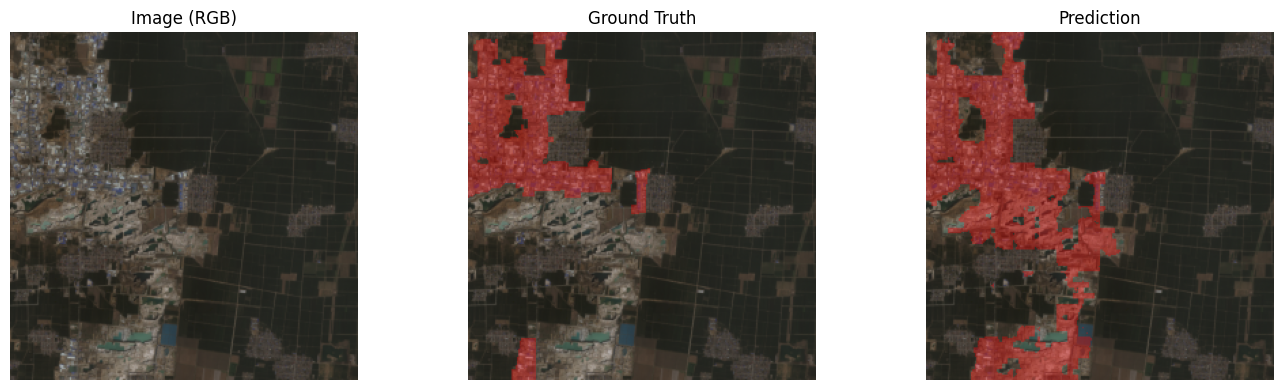

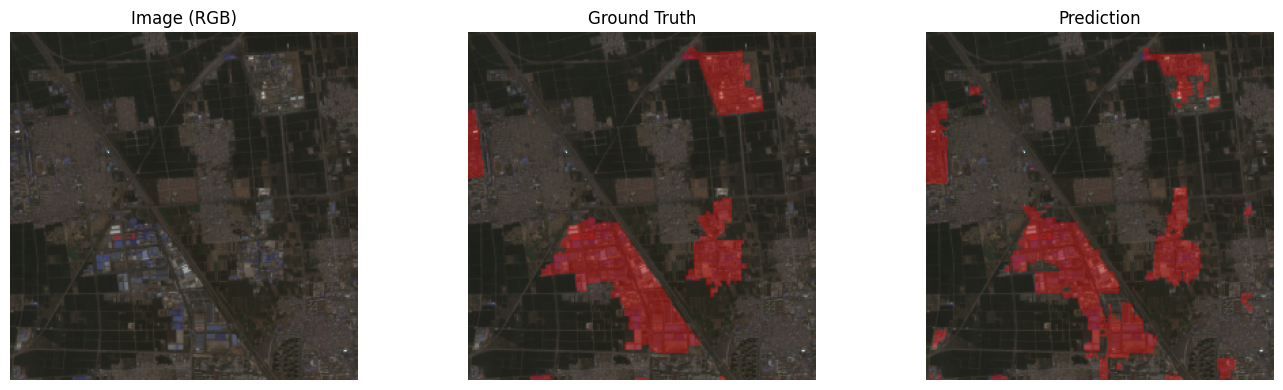

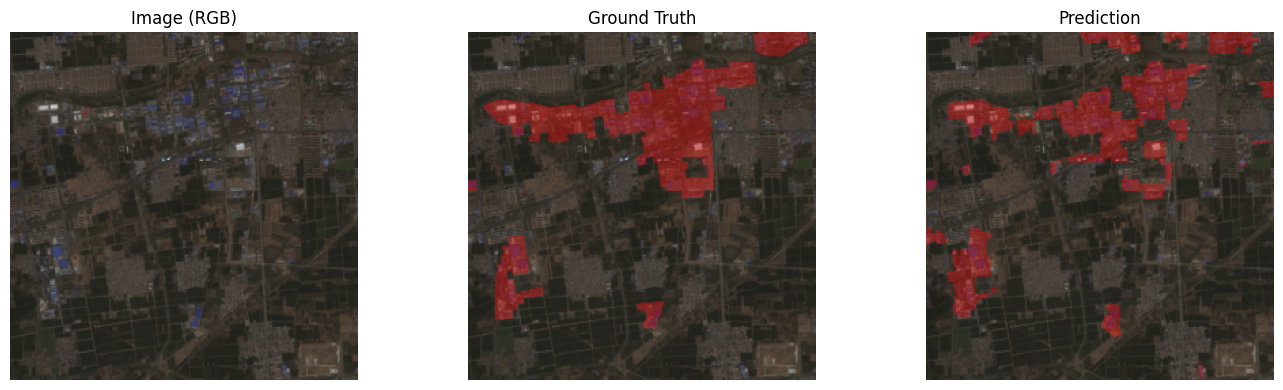

In [9]:
#@title 9. 최종 평가 및 시각화
# 1. 최적 가중치 로드 및 평가
model.load_weights(CKPT_PATH)
res = model.evaluate(valid_ds, return_dict=True, verbose=1)

print("\n--- 최종 성능 지표 (mIoU) ---")
for k, v in res.items():
    print(f"  - {k:12s}: {float(v):.4f}")
print("--------------------")

# 2. 시각화 함수 (5채널 -> 3채널 RGB 변환 후 출력)
def overlay_red(img, mask01, alpha=0.35):
    img = img.astype(np.float32)
    red = np.zeros_like(img, dtype=np.float32); red[..., 0] = 1.0
    vis_img = img[..., :3] if img.shape[-1] >= 3 else np.repeat(img[..., :1], 3, axis=-1)
    vis_img = np.clip(vis_img, 0, 1)
    m3  = np.repeat(mask01[..., None], 3, axis=2).astype(np.float32)
    return vis_img*(1 - alpha*m3) + red*(alpha*m3)

def show_samples(ds, n=3):
    for imgs, masks in ds.take(1):
        preds = model.predict(imgs, verbose=0)
        gt = (masks.numpy()[..., 0] > 0.5).astype(np.uint8)
        pr = (preds[..., 0] > 0.5).astype(np.uint8)

        for i in range(min(n, imgs.shape[0])):
            vis = np.clip(imgs[i].numpy()[..., :3], 0, 1) # RGB만 추출
            fig, ax = plt.subplots(1, 3, figsize=(14, 4))
            ax[0].imshow(vis); ax[0].set_title("Image (RGB)"); ax[0].axis("off")
            ax[1].imshow(overlay_red(vis, gt[i])); ax[1].set_title("Ground Truth"); ax[1].axis("off")
            ax[2].imshow(overlay_red(vis, pr[i])); ax[2].set_title("Prediction"); ax[2].axis("off")
            plt.tight_layout(); plt.show()

show_samples(valid_ds, n=3)